In [ ]:
# Wine Dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib as jb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib as jb

LOADING THE DATA ⏳

In [3]:
dataset = pd.read_csv('Wine.csv')
dataset

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
dataset.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Preprocess the Data 📈

In [6]:
dataset.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [7]:
print('Number of unique values: ', dataset.nunique().sum())

print('\n', dataset.nunique())

Number of unique values:  1279

 Wine                      3
Alcohol                 126
Malic.acid              133
Ash                      79
Acl                      63
Mg                       53
Phenols                  97
Flavanoids              132
Nonflavanoid.phenols     39
Proanth                 101
Color.int               132
Hue                      78
OD                      122
Proline                 121
dtype: int64


In [8]:
dataset.duplicated().sum()

np.int64(0)

Exploratory Data Analysis 📊

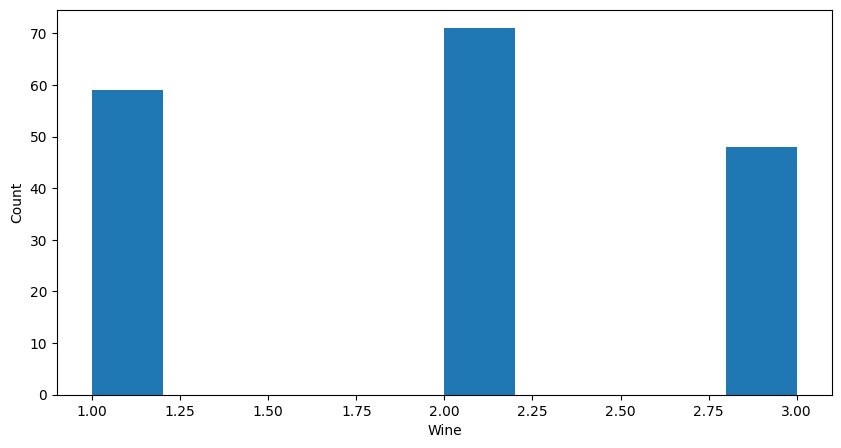

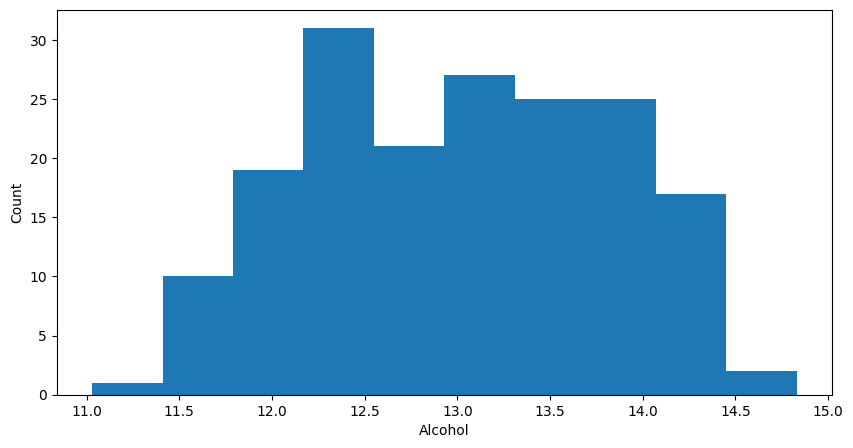

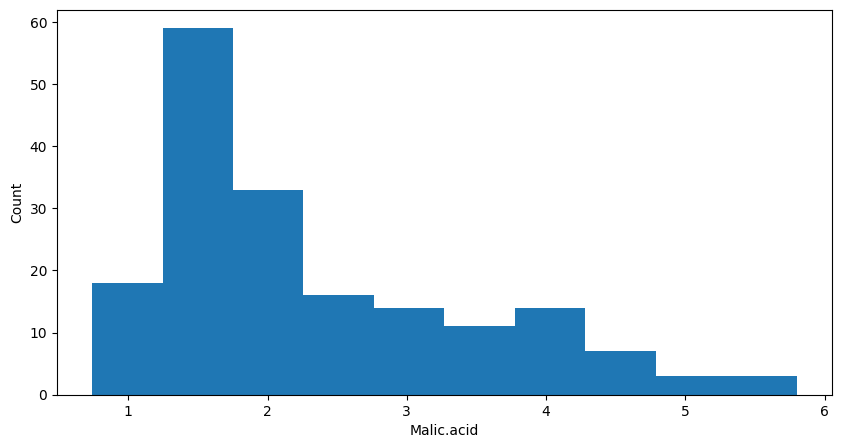

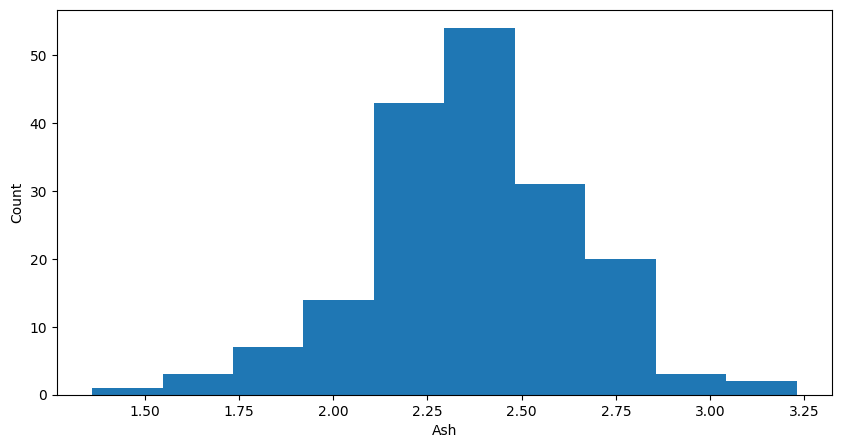

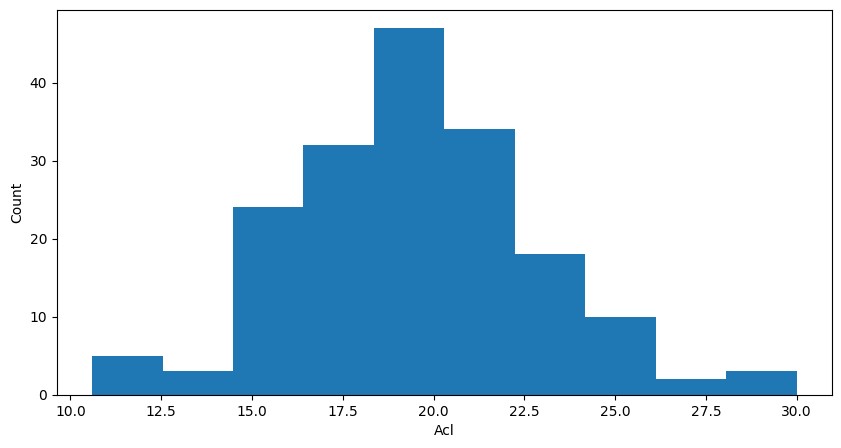

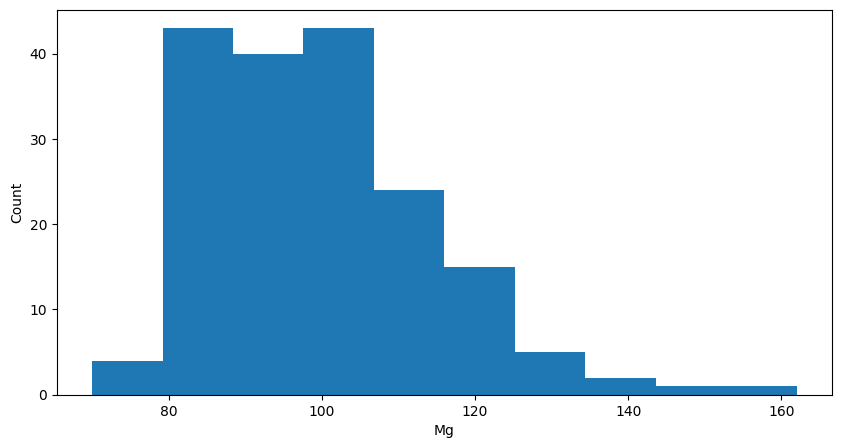

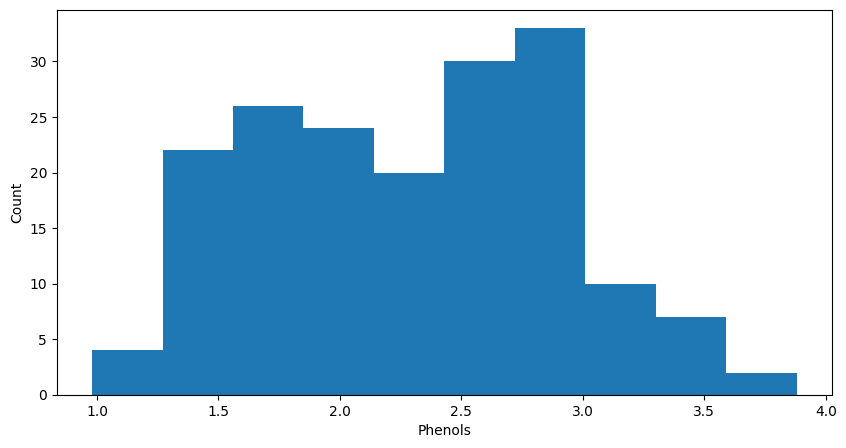

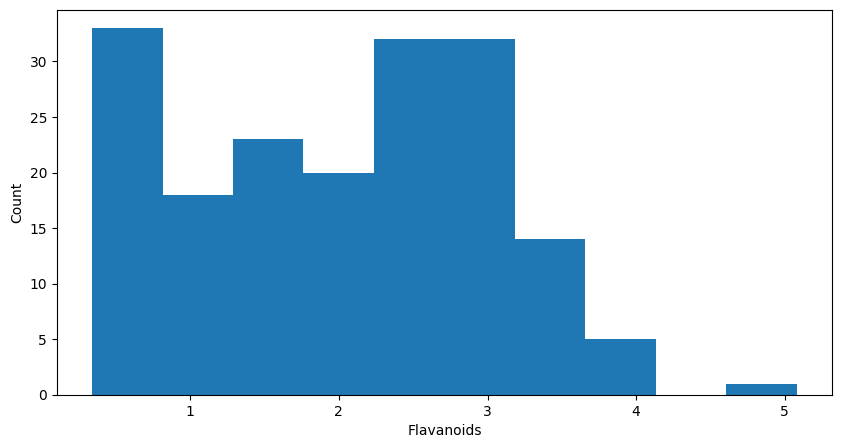

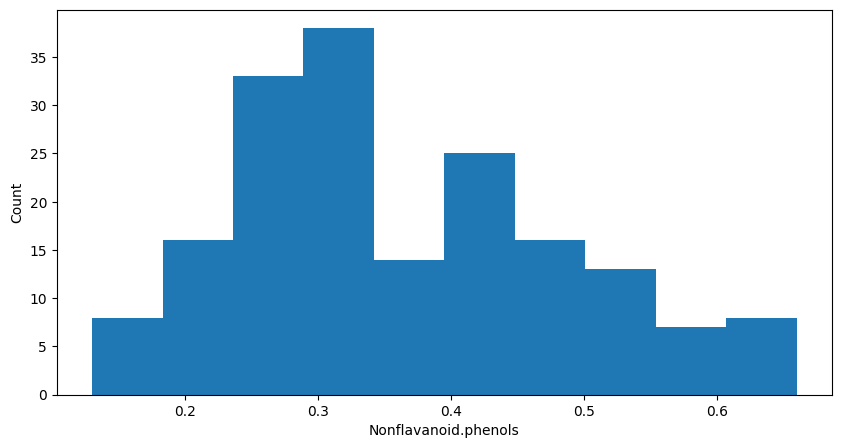

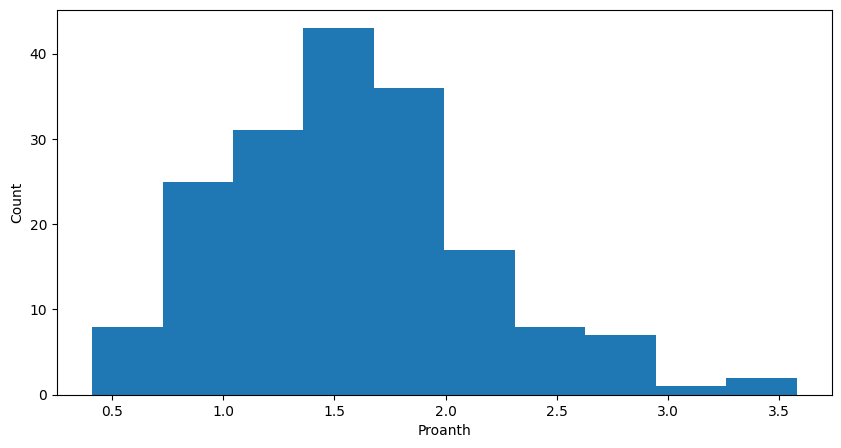

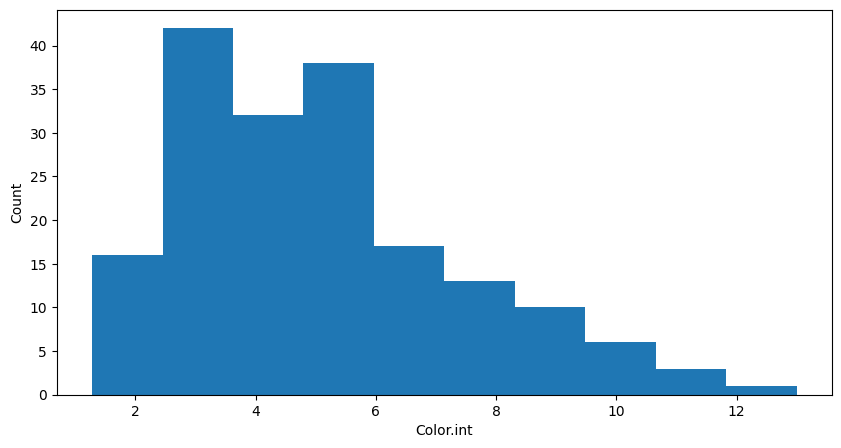

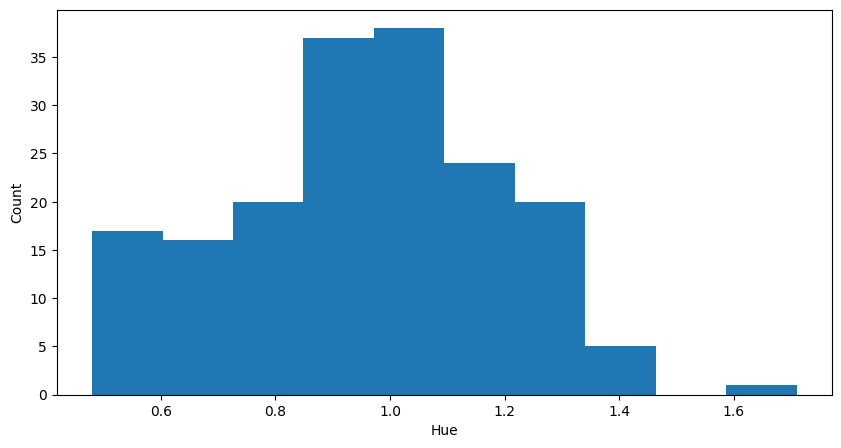

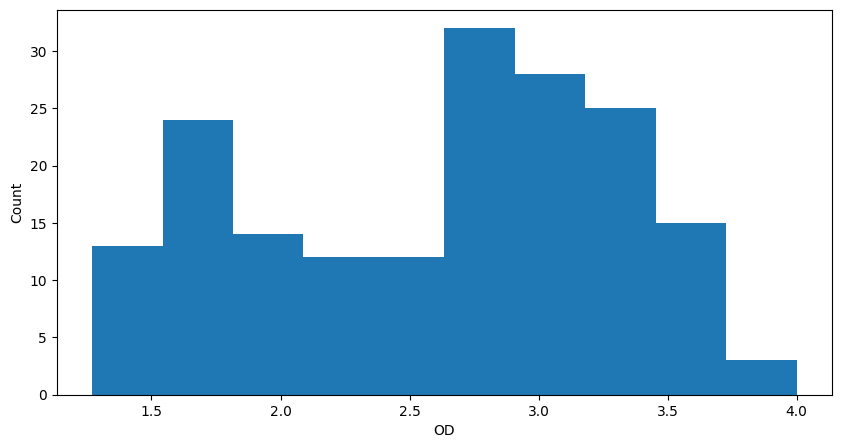

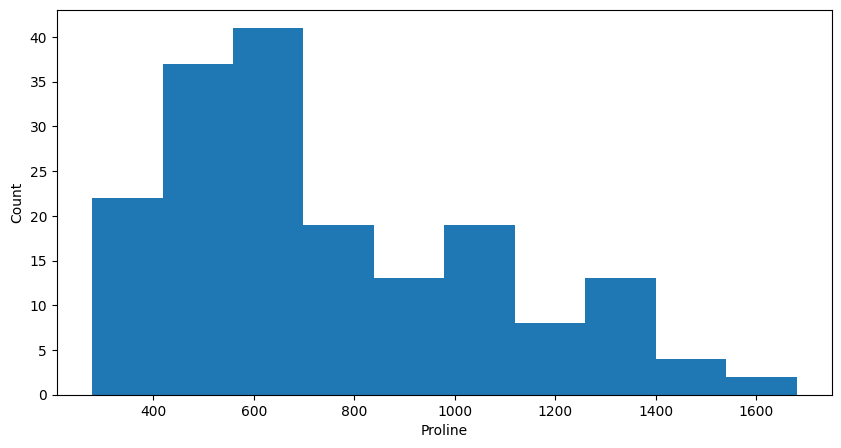

In [9]:
#histograms
features = dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    plt.hist(dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [12]:
#now plotting the correlation matrix
correlation_matrix = dataset.corr()
correlation_matrix

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic.acid,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Acl,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Mg,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid.phenols,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanth,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


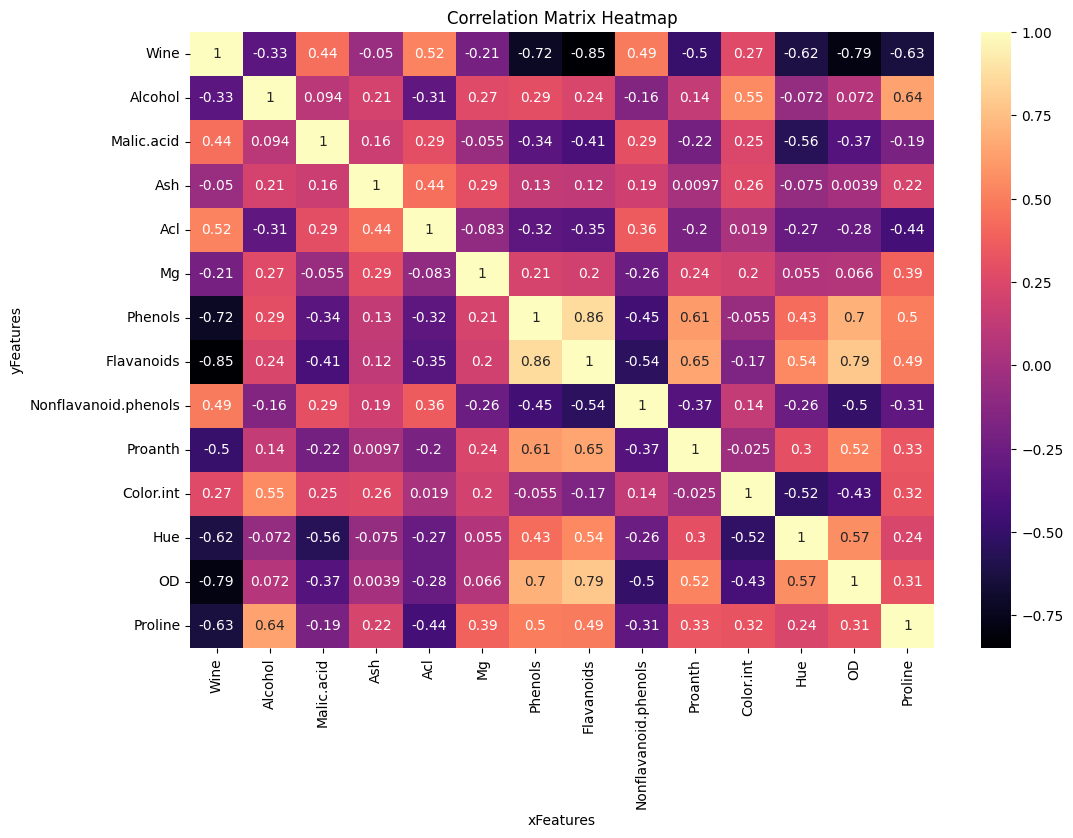

In [13]:
#now using heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap = 'magma')
plt.title('Correlation Matrix Heatmap')
plt.xlabel('xFeatures')
plt.ylabel('yFeatures')
plt.show()

In [14]:
#now drop unnecessary columns 
dataset.drop(['Ash', 'Mg', 'Color.int'], axis=1, inplace = True)
dataset

,Wine,Alcohol,Malic.acid,Acl,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Hue,OD,Proline
0,1,14.23,1.71,15.6,2.80,3.06,0.28,2.29,1.04,3.92,1065
1,1,13.20,1.78,11.2,2.65,2.76,0.26,1.28,1.05,3.40,1050
2,1,13.16,2.36,18.6,2.80,3.24,0.30,2.81,1.03,3.17,1185
3,1,14.37,1.95,16.8,3.85,3.49,0.24,2.18,0.86,3.45,1480
4,1,13.24,2.59,21.0,2.80,2.69,0.39,1.82,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,20.5,1.68,0.61,0.52,1.06,0.64,1.74,740
174,3,13.40,3.91,23.0,1.80,0.75,0.43,1.41,0.70,1.56,750
175,3,13.27,4.28,20.0,1.59,0.69,0.43,1.35,0.59,1.56,835
176,3,13.17,2.59,20.0,1.65,0.68,0.53,1.46,0.60,1.62,840


Pipeline 

In [15]:
X = dataset.drop('Wine', axis=1)
y = dataset['Wine']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()


In [16]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical: impute missing with most frequent, then one-hot encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine transformers
preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [17]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])


In [18]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])


In [19]:
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

In [22]:
print('accuracy_score: ', accuracy_score(y_test, dt_preds) * 100)

accuracy_score:  88.88888888888889


In [23]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       0.87      0.93      0.90        14
           3       0.83      0.62      0.71         8

    accuracy                           0.89        36
   macro avg       0.88      0.85      0.86        36
weighted avg       0.89      0.89      0.88        36



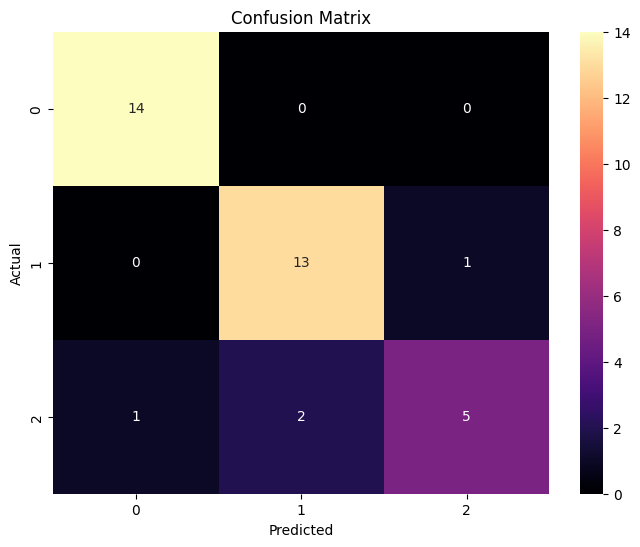

In [24]:
#confusion matrix for decision tree
confusion_matrix = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [25]:
knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

In [26]:
print('accuracy_score: ', accuracy_score(y_test, knn_preds) * 100)

accuracy_score:  94.44444444444444


In [27]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       0.87      0.93      0.90        14
           3       0.83      0.62      0.71         8

    accuracy                           0.89        36
   macro avg       0.88      0.85      0.86        36
weighted avg       0.89      0.89      0.88        36



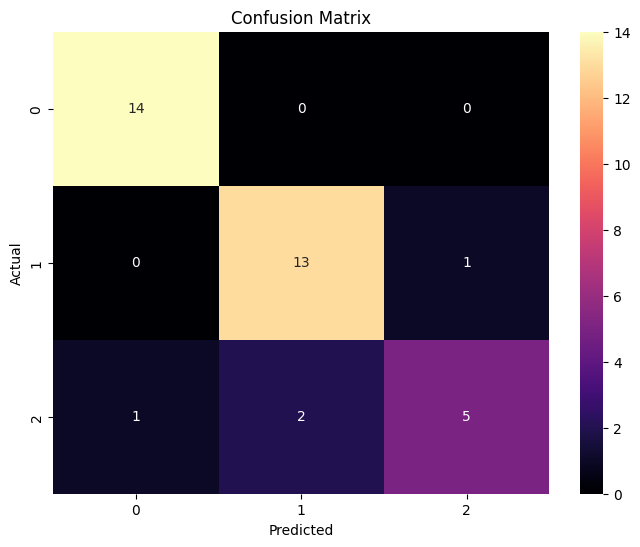

In [28]:
#confusion matrix for decision tree
confusion_matrix = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)


In [30]:
print('accuracy_score: ', accuracy_score(y_test, dt_preds) * 100)

accuracy_score:  88.88888888888889


In [31]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       0.87      0.93      0.90        14
           3       0.83      0.62      0.71         8

    accuracy                           0.89        36
   macro avg       0.88      0.85      0.86        36
weighted avg       0.89      0.89      0.88        36



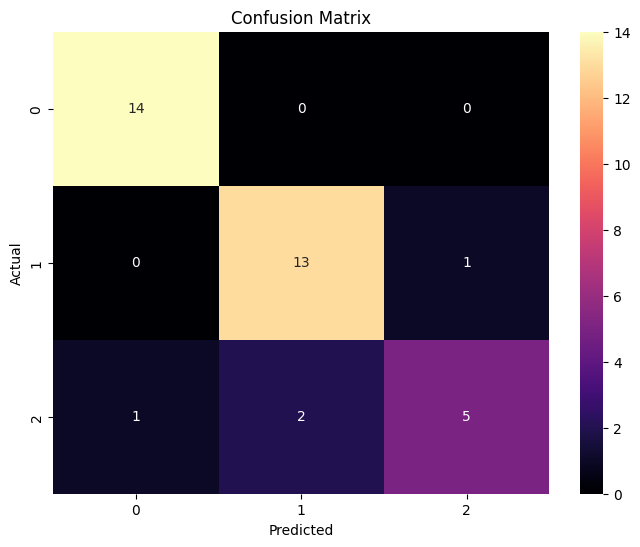

In [32]:
#confusion matrix for decision tree
confusion_matrix = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
dt_cv = cross_val_score(dt_pipeline, X_train, y_train, cv=5)
knn_cv = cross_val_score(knn_pipeline, X_train, y_train, cv=5)
nb_cv = cross_val_score(nb_pipeline, X_train, y_train, cv=5)

print("Decision Tree CV Mean:", dt_cv.mean())
print("KNN CV Mean:", knn_cv.mean())
print("Naive Bayes CV Mean:", nb_cv.mean())


Decision Tree CV Mean: 0.887192118226601
KNN CV Mean: 0.9507389162561577
Naive Bayes CV Mean: 0.9507389162561577
